Appendix for JC Penney Consultancy Job

In [211]:
# Import Libraries 
import pandas as pd
import numpy as np
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Step 1: Data Loading and Initial Inspection

The first section of this code will include loading the data and verifying the structure for future use.

In this step:

- Two json files and the three csv files were loaded.
- A dictionary was used to manage the csvs effectively.
- The record counts were printed.
- The first ten rows of all data were then printed to gain an understanding of structure and content.
- This step ensures all data is loaded and visible and some initial information on the dataset is ascertained.

This is a crucial, initial step to understand what the data looks like structurally without printing a large amount of data. Data loading and initial inspection are essential to establish a clear understanding of the structure, completeness, and reliability of each dataset before any analysis begins. Managing the CSVs through a dictionary streamlines access and reduces redundancy when referencing multiple datasets. This foundational step ensures the downstream cleaning, merging, and modelling stages are built on correctly structured and validated data.

In [212]:
# Load in the JSON files
products_json_df = pd.read_json("jcpenney_products.json", lines=True)
reviewers_json_df = pd.read_json("jcpenney_reviewers.json", lines=True)

print(f"Products JSON: {len(products_json_df)} rows  |  "
      f"Reviewers JSON: {len(reviewers_json_df)} rows")

# Load in the CSV files
csv_files = {
    name: pd.read_csv(f"{name.lower()}.csv")
    for name in ["Products", "Reviews", "Users"]
}
for name, df in csv_files.items():
    print(f"{name} CSV: {len(df)} rows")
    display(df.head(4))

# Unpack dataframes for later use
products_csv_df, reviews_csv_df, users_csv_df = csv_files.values()

Products JSON: 7982 rows  |  Reviewers JSON: 5000 rows
Products CSV: 7982 rows


,Uniq_id,SKU,Name,Description,Price,Av_Score
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.000
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,2.625
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,Youll return to our Alfred Dunner pull-on capr...,41.09,3.500


Reviews CSV: 39063 rows


,Uniq_id,Username,Score,Review
0,b6c0b6bea69c722939585baeac73c13d,fsdv4141,2,You never have to worry about the fit...Alfred...
1,b6c0b6bea69c722939585baeac73c13d,krpz1113,1,Good quality fabric. Perfect fit. Washed very ...
2,b6c0b6bea69c722939585baeac73c13d,mbmg3241,2,I do not normally wear pants or capris that ha...
3,b6c0b6bea69c722939585baeac73c13d,zeqg1222,0,I love these capris! They fit true to size and...


Users CSV: 5000 rows


,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida


Step 2: Data Understanding and Quality Check

Before cleaning and merging, the datasets are explored to assess the structure and quality.

In this step:

- Column names are reviewed for each dataset.
- Missing values are identified and summarised.
- A visual heatmap highlights patterns of missing data.
- This step ensures that any inconsistencies or incomplete records can be addressed before further analysis.

To ensure the datasets were suitable for analysis, a concise summary of rows, columns, and missing values was produced to give an immediate understanding of data completeness and structure. A missing-data heatmap was then used because binary visual contrast makes gaps in the data instantly recognisable without scanning numeric tables. This early diagnostic step ensures that all subsequent cleaning, merging, and modelling processes are built on a reliable and well-understood foundation.

,Dataset,Rows,Columns,Total Missing
0,Products CSV,7982,6,2776
1,Reviews CSV,39063,4,0
2,Users CSV,5000,3,0
3,Products JSON,7982,15,0
4,Reviewers JSON,5000,4,0


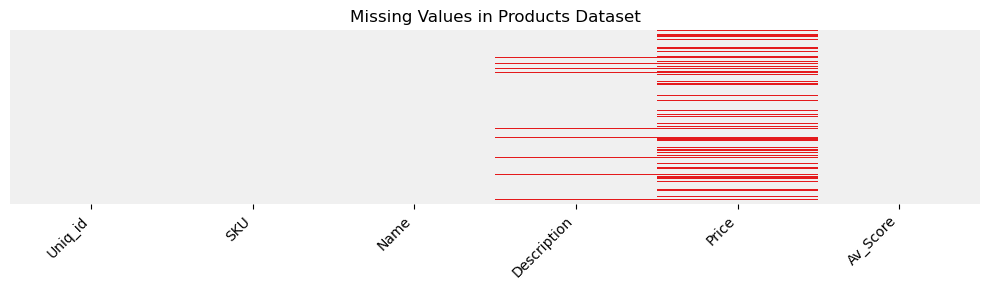

In [213]:
# Collect all datasets into one dictionary
datasets = {
    "Products CSV": products_csv_df,
    "Reviews CSV": reviews_csv_df,
    "Users CSV": users_csv_df,
    "Products JSON": products_json_df,
    "Reviewers JSON": reviewers_json_df
}
# Create a summary of rows, columns, and total missing values
summary = []
for name, df in datasets.items():
    summary.append([
        name,
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum()
    ])
summary_df = pd.DataFrame(summary, columns=["Dataset", "Rows", "Columns", "Total Missing"])
display(summary_df)

# Visualise missing values for a dataset with missing entries
plt.figure(figsize=(10, 3))
sns.heatmap(
    products_csv_df.isna(),
    cbar=False,
    cmap=["#f0f0f0", "#e41a1c"]
)
plt.title("Missing Values in Products Dataset")
plt.xticks(rotation=45, ha='right')
plt.yticks([])
plt.tight_layout()
plt.show()

Step 3: Data Cleaning and Preparation After assessing the data structure and quality, the next step is to clean and standardise it to ensure consistency across files before merging.

In this step:

- All column names were standardised by converting to lowercase and key fields were renamed for consistency. 
- Missing prices and discount information were flagged, enabling later filtering without discarding records.
- User birthdates were converted into a standard datetime format, and age was derived as a continuous variable.
  
The approach to missing data was to flag rather than delete observations, preserving coverage while still enabling selective exclusion when necessary. This was especially important for product pricing, where deleting rows with missing values would have removed over 2,000 products (around 27% of the dataset). By retaining these records with clear indicators, the analysis remains comprehensive while still supporting comparisons between complete and incomplete entries. Finally, converting user birthdates to a standard date format and deriving age adds an essential demographic variable for segmentation and downstream persona modelling.

In [214]:
# Standardise column names
def clean(df):
    df.columns = df.columns.str.strip().str.lower()
    return df

products_csv_df, reviews_csv_df, users_csv_df, products_json_df, reviewers_json_df = [
    clean(d) for d in [
        products_csv_df, reviews_csv_df, users_csv_df,
        products_json_df, reviewers_json_df
    ]
]
# Unify ID column names
for d in [products_csv_df, reviews_csv_df, users_csv_df,
          products_json_df, reviewers_json_df]:
    d.rename(columns={"uniq_id":"product_id",
                      "username":"user_id"}, inplace=True)
# Clean price fields + flags
dfp = products_json_df
for col in ["list_price", "sale_price"]:
    if col in dfp:
        dfp[col] = (
            dfp[col].astype(str)
            .str.extract(r"(\d+\.?\d*)")[0]
            .astype(float)
        )
dfp["price_missing_flag"] = dfp[["list_price","sale_price"]].isna().any(axis=1).astype(int)
dfp["discount_flag"] = ((dfp["sale_price"] < dfp["list_price"]) &
                        dfp["sale_price"].notna()).astype(int)
dfp["discount_percent"] = np.where(
    dfp["discount_flag"],
    ((dfp["list_price"] - dfp["sale_price"]) /
     dfp["list_price"] * 100).round(2),
    np.nan
)

# Clean and standardize birthdates and compute age in years

users_csv_df["dob"] = pd.to_datetime(users_csv_df["dob"], errors="coerce", format="%d.%m.%Y")
users_csv_df["age"] = ((pd.Timestamp("today") - users_csv_df["dob"]).dt.days / 365.25).round(1)

# Summary + preview
print(
    "Missing price:", dfp["price_missing_flag"].sum(),
    "| Discounts:", dfp["discount_flag"].sum(),
    "| Users missing DOB:", u["dob"].isna().sum()
)

display(dfp[["product_id","list_price","sale_price",
             "discount_flag","discount_percent",
             "price_missing_flag"]].head())

display(u[["user_id","dob","age","age_group"]].head())

Missing price: 2166 | Discounts: 5772 | Users missing DOB: 0


,product_id,list_price,sale_price,discount_flag,discount_percent,price_missing_flag
0,b6c0b6bea69c722939585baeac73c13d,41.09,24.16,1,41.2,0
1,93e5272c51d8cce02597e3ce67b7ad0a,41.09,24.16,1,41.2,0
2,013e320f2f2ec0cf5b3ff5418d688528,41.09,24.16,1,41.2,0
3,505e6633d81f2cb7400c0cfa0394c427,41.09,24.16,1,41.2,0
4,d969a8542122e1331e304b09f81a83f6,41.09,24.16,1,41.2,0


,user_id,dob,age,age_group
0,bkpn1412,1983-07-31,42.3,40–60
1,gqjs4414,1998-07-27,27.3,25–40
2,eehe1434,1950-08-08,75.3,60+
3,hkxj1334,1969-08-03,56.3,40–60
4,jjbd1412,2001-07-26,24.3,<25


Step 4: Data Verification and Visual Exploration

After ensuring the datasets were fully cleaned, the next step was to verify their structure and begin exploring key patterns in the data.

In this step:

- The ten most common brands were identified and their average sale prices visualised.

- Review, product, and user datasets were merged to link customer location with product pricing.

- Total sales values were aggregated for each state, and the top ten were plotted to reveal where spending is most concentrated.

The lollipop chart communicates differences in average sale price using a clean positional scale, which is one of the most accurate visual encodings. Replacing full bars with markers reduces unnecessary ink and keeps attention on the comparison rather than the chart elements themselves. The horizontal orientation improves readability for brand names and allows for a straightforward ranked layout. Overall, the design highlights price contrasts. The line plot arranges states in ascending order, making relative differences in sales value easy to interpret. Connecting the points emphasises the progression across the ranking while keeping the visual simple and minimal. Because the design avoids excessive styling or distracting elements, the viewer can immediately focus on which states contribute the most sales. This approach supports clear, priority-driven insight for decision-making.

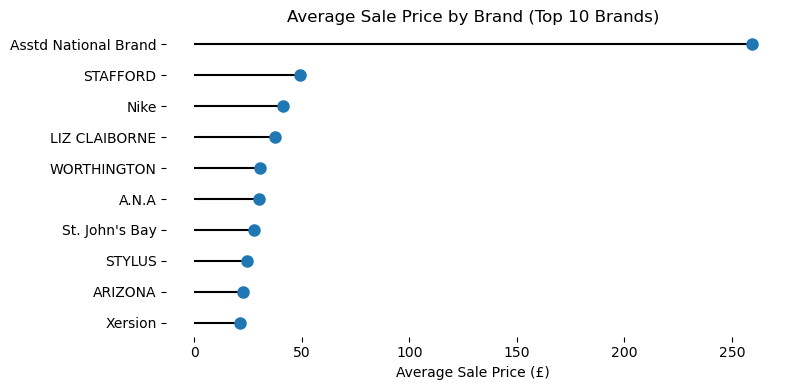

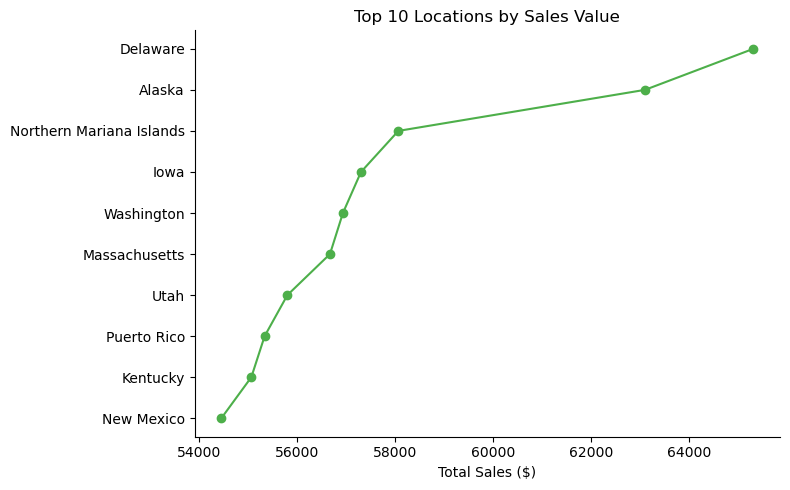

In [204]:
# Calculate the Top 10 brands
top_brands = (
    products_json_df["brand"]
    .value_counts()
    .head(10)
    .index
)

# Calculate the average sale price for those top brands
df_brand = (
    products_json_df[products_json_df["brand"].isin(top_brands)]
    .groupby("brand")["sale_price"]
    .mean()
    .sort_values()
)

# Visualise with a Lollipop chart: average price by brand
plt.figure(figsize=(8,4))
plt.hlines(y=df_brand.index, xmin=0, xmax=df_brand.values, color="black")
plt.plot(df_brand.values, df_brand.index, "o", markersize=8, color="#1f77b4")

plt.title("Average Sale Price by Brand (Top 10 Brands)")
plt.xlabel("Average Sale Price (£)")
plt.ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Build merged dataset for sales by location
df = (
    reviews_csv_df
    .merge(reviewers_json_df[['user_id','state']], on='user_id', how='inner')
    .merge(products_json_df[['product_id','sale_price','price_missing_flag']],
           on='product_id', how='inner')
    .query("state.notna() & sale_price.notna() & price_missing_flag == 0")
)

# Calculate total sales per location
sales_by_state = df.groupby("state")["sale_price"].sum().sort_values(ascending=False)

# Plot top 10 locations
vals = sales_by_state.head(10).sort_values()

plt.figure(figsize=(8,5))
plt.plot(vals.values, vals.index, "o-", color="#4daf4a")
plt.title("Top 10 Locations by Sales Value")
plt.xlabel("Total Sales ($)")
sns.despine()
plt.tight_layout()
plt.show()

Step 5: Sentiment Processing 

With the review text cleaned and prepared, the next step was to apply sentiment analysis and combine this enriched review data with product and user information to build customer personas.

In this step:

- The VADER sentiment model was loaded and applied to each review to generate a compound sentiment score.

- Review data was further cleaned by standardising column names, removing empty entries, and validating rating values.

- The cleaned review dataset was merged with product details and user demographic data to create a unified view of each customer’s interactions.

The decision was made to calculate the sentiment for the reviews which is appropriate here because written reviews carry opinion-based information that cannot be captured with solely numerical ratings. VADER is optimised for short, informal text such as online product reviews which makes it well-suited to this dataset. By converting free-text feedback into a quantitative senitment score, we can systematically capture customers' expressed attitudes and integrate this behavioural signal with ratings, spend and demographics. This enriched representation enables more accurate persona profiling and reveals nuances in customer experience. 

In [215]:
# Clean review data
df = (reviews_csv_df.copy()
      .rename(columns={'review':'review_text','score':'rating'})
      .assign(review_text=lambda x: x['review_text'].astype(str).str.strip())
      .dropna(subset=['review_text']))

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df[df['rating'].between(0, 5)]

# Sentiment scoring
df['sentiment_score'] = df['review_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

print(f"Valid reviews: {len(df):,} | Avg rating: {df['rating'].mean():.2f} | "
      f"Avg sentiment: {df['sentiment_score'].mean():.2f}")
display(df[['user_id','product_id','rating','sentiment_score','review_text']].head(4))

# Merge reviews → products → users
merged = (df
          .merge(products_json_df, on="product_id", how="left")
          .merge(users_csv_df, on="user_id", how="left"))

print(f"Merged dataset: {len(merged):,} rows")

Valid reviews: 39,063 | Avg rating: 1.49 | Avg sentiment: 0.67


,user_id,product_id,rating,sentiment_score,review_text
0,fsdv4141,b6c0b6bea69c722939585baeac73c13d,2,0.9423,You never have to worry about the fit...Alfred...
1,krpz1113,b6c0b6bea69c722939585baeac73c13d,1,0.8408,Good quality fabric. Perfect fit. Washed very ...
2,mbmg3241,b6c0b6bea69c722939585baeac73c13d,2,0.9514,I do not normally wear pants or capris that ha...
3,zeqg1222,b6c0b6bea69c722939585baeac73c13d,0,0.9329,I love these capris! They fit true to size and...


Merged dataset: 39,080 rows


Step 6: Sentiment Visualisation and Word Analysis

After constructing the persona dataset, visual analysis was used to explore the relationship between sentiment and product ratings, followed by an examination of the most common terms appearing in customer reviews.

In this step:

- A scatterplot was created to show how sentiment scores relate to numerical ratings across users.

- Additional stopwords were added to remove generic or uninformative terms commonly found in clothing reviews.

- A wordcloud was generated to highlight the most frequent meaningful words used across all customer reviews.

The word cloud offers an impression of dominant topics within customer reviews. It is not intended for precise measurement, however, it is effective for identifying recurring themes or sentiments in unstructured text. Removing common or uninformative words improved the interpretability by highlighting genuinely meaningful vocabulary.

The scatter plot is appropriate here because it directly visualises the relationship between two continuous variables, average sentiment and average rating, using spatial position, which is a precise way to show correlation or lack thereof. Plotting individual customers as points reveals the underlying distribution, outliers, and density patterns without imposing assumptions about the form of the relationship. The light transparency reduces overplotting and keeps the chart readable even with a large number of observations. Overall, this visual effectively communicates whether sentiment scores meaningfully align with user rating behaviour.

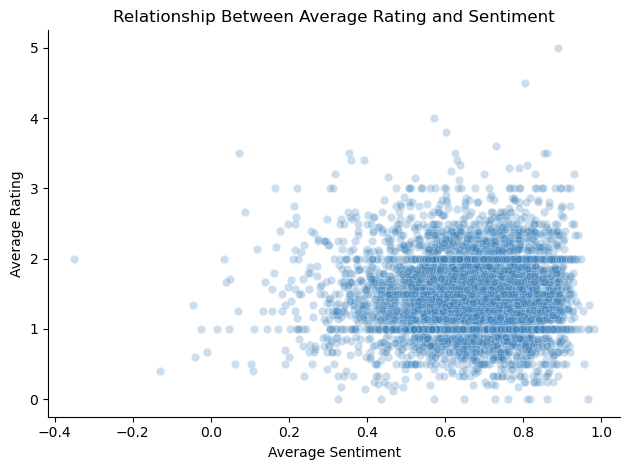

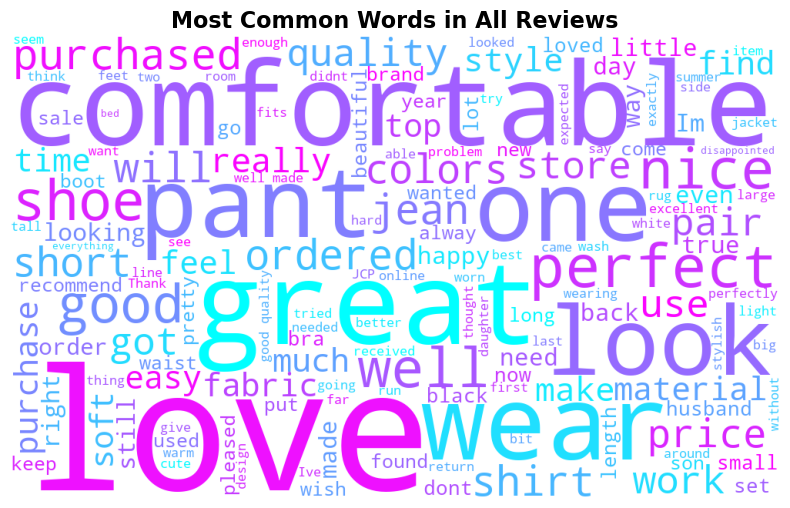

In [216]:
# Build persona dataframe from merged data
persona_df = (
    merged.groupby("user_id")
    .agg(avg_sentiment=("sentiment_score", "mean"),
         avg_rating=("rating", "mean"))
    .dropna(subset=["avg_sentiment", "avg_rating"])
    .reset_index()
)

# Visualise with a scatterplot: sentiment vs rating 
sns.scatterplot(
    data=persona_df,
    x="avg_sentiment",
    y="avg_rating",
    color="#377eb8",
    alpha=0.25
)
plt.title("Relationship Between Average Rating and Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Average Rating")
sns.despine()
plt.tight_layout()
plt.show()

#  Generate a wordcloud: most common review words 
stop = STOPWORDS.union({"dress","buy","bought","size","fit",
                        "product","color"})
wc = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=stop,
    colormap="cool",
    max_words=150
).generate(" ".join(df["review_text"].dropna()))

plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Most Common Words in All Reviews", fontsize=16, weight="bold")
plt.show()

Step 7: Data-Driven Persona Segmentation

To create objective and reliable personas, a K-Means clustering model was applied to customers with complete behavioural data.

In this step:

- Only customers with complete values for the five clustering features: average rating, average sentiment, age, review count, and average spend were included, ensuring no imputation or artificial data. Customers with missing values were retained in the master dataset but excluded from the clustering step.

- All features were standardised so each metric contributed equally to the clustering process.

- A stable K-Means model (fixed seeds and multiple initialisations) was used to identify four behavioural groups. 

- Cluster labels were written back to the full dataset, with incomplete cases left unassigned.

- Cluster centroids were converted back to original units (e.g., actual age and spend) for clear interpretation.

K-Means works best when data forms roughly round clusters and can be affected by extreme values. Although all features were standardised, no extra checks for outliers or skew were applied, so patterns involving variables like spend and review count should be interpreted with this in mind.
The analysis used four clusters without formally testing whether four was the best number. The choice worked for the project, but methods like the elbow or silhouette tests would help confirm whether four clusters truly fit the data well or if another number might be better.

Clustering was used to identify customer personas because it detects natural behavioural groupings in the data to find out what kind of customers make up their customer base. By analysing patterns in sentiment, rating behaviour, age, review activity and spend, the method reveals underlying similarities that are not visible through manual inspection. K Means is well suited here because it handles numerical features efficiently, scales to thousands of customers and produces stable, interpretable clusters once the data is standardised. This data driven segmentation provides the business with actionable insight into distinct customer types, supporting more targeted marketing and product strategy.

In [217]:
# Build user-level persona dataset 

# Find average of all aspects and number of reviews/products.Then calculate favourite category.
persona_df = (
    merged.groupby("user_id")
    .agg({
        "rating": "mean",                 
        "sentiment_score": "mean",        
        "age": "mean",                   
        "product_id": "count",            
        "sale_price": "mean",              
        "category": lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown" 
    })
    .rename(columns={
        "rating": "avg_rating",
        "sentiment_score": "avg_sentiment",
        "age": "avg_age",
        "product_id": "review_count",
        "sale_price": "avg_price",
        "category": "fav_category"
    })
    .reset_index()
)
# Select clustering features 
features = ['avg_rating','avg_sentiment','avg_age','review_count','avg_price']

# Keep only customers with complete data 
df_clust = persona_df.dropna(subset=features)
print(f"Using {len(df_clust)} customers for clustering")
print(f"{len(persona_df) - len(df_clust)} customers excluded due to missing values\n")

# Scale features to equalise influence 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust[features])

# Run stable K-means clustering 
np.random.seed(42)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=50, max_iter=500)
labels = kmeans.fit_predict(X_scaled)

# Store cluster labels back in the full persona_df 
persona_df['cluster'] = pd.NA
persona_df.loc[df_clust.index, 'cluster'] = labels

print("Customers per cluster:")
print(pd.Series(labels).value_counts().sort_index())

# Convert centroids back to original units (for interpretation)
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)
centroids.index.name = "cluster"

print("\nCluster centroids (original units):")
display(centroids)

Using 4993 customers for clustering
0 customers excluded due to missing values

Customers per cluster:
0    1869
1     291
2    1848
3     985
Name: count, dtype: int64

Cluster centroids (original units):


,avg_rating,avg_sentiment,avg_age,review_count,avg_price
cluster,,,,,
0,1.51,0.72,35.89,8.12,77.96
1,1.54,0.66,52.19,7.35,493.81
2,1.48,0.73,63.09,8.24,75.33
3,1.43,0.45,51.86,6.64,80.22


Step 8: Persona Comparison Visualisation

This step visualises how the four data-driven personas differ across the key behavioural metrics used in the segmentation.

In this step:

- Cluster IDs are mapped to descriptive persona names so each customer is assigned to an interpretable group.

- Persona-level averages are computed for the five behavioural metrics: rating, sentiment, age, review count, and spend.

- These averages are normalised so that all metrics share a comparable 0–1 scale for colour encoding.

- Formatted metric values are prepared as annotations to retain the actual numbers in the visualisation.

- A heatmap is generated to compare personas across all metrics in a single compact, interpretable display.

This heatmap is an effective choice for comparing personas because it condenses multiple behavioural metrics into a single, structured visual layout. Colour intensity immediately highlights relative differences between personas, making patterns in sentiment, spending, engagement, and age easy to spot without scanning multiple charts. Including the actual metric values as annotations preserves numerical accuracy while keeping the design clean and readable.

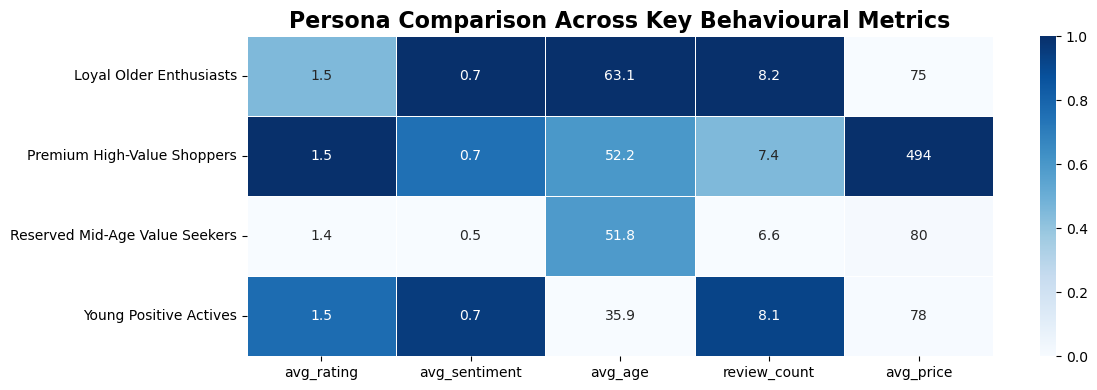

In [218]:
# Map cluster IDs to persona names
persona_labels = {
    0: "Young Positive Actives",
    1: "Premium High-Value Shoppers",
    2: "Loyal Older Enthusiasts",
    3: "Reserved Mid-Age Value Seekers"
}
persona_df["persona_name"] = persona_df["cluster"].map(persona_labels)

# # Define persona names, behavioural metrics, and corresponding colours
personas = list(persona_labels.values())
metrics = ["avg_rating","avg_sentiment","avg_age","review_count","avg_price"]
colors = {
    "Young Positive Actives": "#82B2FF",
    "Premium High-Value Shoppers": "#F28E8E",
    "Loyal Older Enthusiasts": "#8FD19E",
    "Reserved Mid-Age Value Seekers": "#FFCE67"
}

# Compute mean behavioural values for each persona
means = (
    persona_df[persona_df["persona_name"].isin(personas)]
    .groupby("persona_name")[metrics]
    .mean()
)

# Normalise for colouring and format labels
norm_means = (means - means.min()) / (means.max() - means.min())
annot = means.copy().round(1)
annot["avg_price"] = means["avg_price"].round(0).astype(int)
annot = annot.astype(str)

# Create the heatmap to compare personas across all metrics
plt.figure(figsize=(12,4))
sns.heatmap(norm_means, annot=annot, fmt="", cmap="Blues",
            linewidths=0.4, linecolor="white", cbar=True)

plt.title("Persona Comparison Across Key Behavioural Metrics",
          fontsize=16, weight="bold")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.show()

In [219]:
%%capture
!jupyter nbconvert "2718233_BD2.ipynb" --to html